<a href="https://colab.research.google.com/github/BernardoBremer/Transfer_learning_actividad/blob/main/transfer_learning_actividad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Instalación de dependencias

In [1]:
# pillow-heif agrega soporte para HEIC/HEIF (formato nativo de iPhone/iPad)
!pip install -q pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 43.5 MB/s eta 0:00:00


## 1. Imports y configuracion

In [2]:
import os
import random
import copy
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from PIL import Image
from tqdm import tqdm

# Registrar soporte HEIC/HEIF (fotos de iPhone)
import pillow_heif
pillow_heif.register_heif_opener()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cpu


## 2. Cargar Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Ruta al drive
DATA_DIR = Path('/content/drive/MyDrive/ICO_Transfer_learning')

print('Carpetas detectadas:', sorted([f.name for f in DATA_DIR.iterdir() if f.is_dir()]))

Mounted at /content/drive
Carpetas detectadas: ['Alex', 'Bremer', 'Edgar', 'Hugo', 'Otros']


## 3. Conversion automatica de imagenes a JPG

Este script recorre todas las subcarpetas y convierte cualquier imagen al formato `.jpg`.  


In [4]:
OK_EXTS  = {'.jpg', '.jpeg'}   # ya estan bien y no se tocan
IMG_EXTS = {'.png', '.webp', '.bmp', '.tiff', '.tif',
            '.gif', '.heic', '.heif', '.avif', '.jfif'}

def convert_images_to_jpg(root: Path):
    converted, skipped, errors = 0, 0, 0

    all_files = sorted(root.rglob('*'))
    for fpath in tqdm(all_files, desc='Revisando archivos'):
        if not fpath.is_file():
            continue

        ext = fpath.suffix.lower()

        if ext in OK_EXTS:
            skipped += 1
            continue

        # Saltar archivos claramente no-imagen
        if ext not in IMG_EXTS and ext not in {'', '.ds_store'}:
            continue

        new_path = fpath.with_suffix('.jpg')
        try:
            img = Image.open(fpath).convert('RGB')
            img.save(new_path, 'JPEG', quality=95)
            fpath.unlink()  # borrar original
            converted += 1
        except Exception as e:
            print(f'  No se pudo convertir {fpath.name}: {e}')
            errors += 1


    print(f'   Ya eran JPG (sin cambios): {skipped}')
    print(f'   Convertidas a JPG:         {converted}')
    print(f'   Errores:                   {errors}')


convert_images_to_jpg(DATA_DIR)

Revisando archivos: 100%|██████████| 250/250 [00:00<00:00, 1379.65it/s]

   Ya eran JPG (sin cambios): 245
   Convertidas a JPG:         0
   Errores:                   0


## 4. EDA  

In [5]:
eda_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = ImageFolder(root=str(DATA_DIR), transform=eda_transform)

CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Clases detectadas ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total de imágenes: {len(full_dataset)}')

class_counts = defaultdict(int)
for _, label in full_dataset.samples:
    class_counts[CLASS_NAMES[label]] += 1

print('\nImagenes por clase:')
for cls, count in class_counts.items():
    print(f'  {cls}: {count}')

Clases detectadas (5): ['Alex', 'Bremer', 'Edgar', 'Hugo', 'Otros']
Total de imágenes: 245

Imagenes por clase:
  Alex: 34
  Bremer: 31
  Edgar: 30
  Hugo: 30
  Otros: 120


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


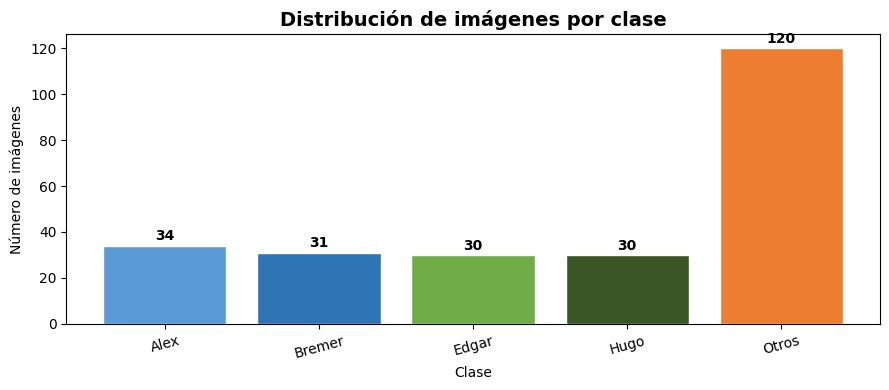

In [7]:
palette = ['#5B9BD5', '#2E75B6', '#70AD47', '#375623', '#ED7D31']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=palette[:NUM_CLASSES], edgecolor='white')
ax.set_title('Distribución de imágenes por clase', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase'); ax.set_ylabel('Número de imágenes')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

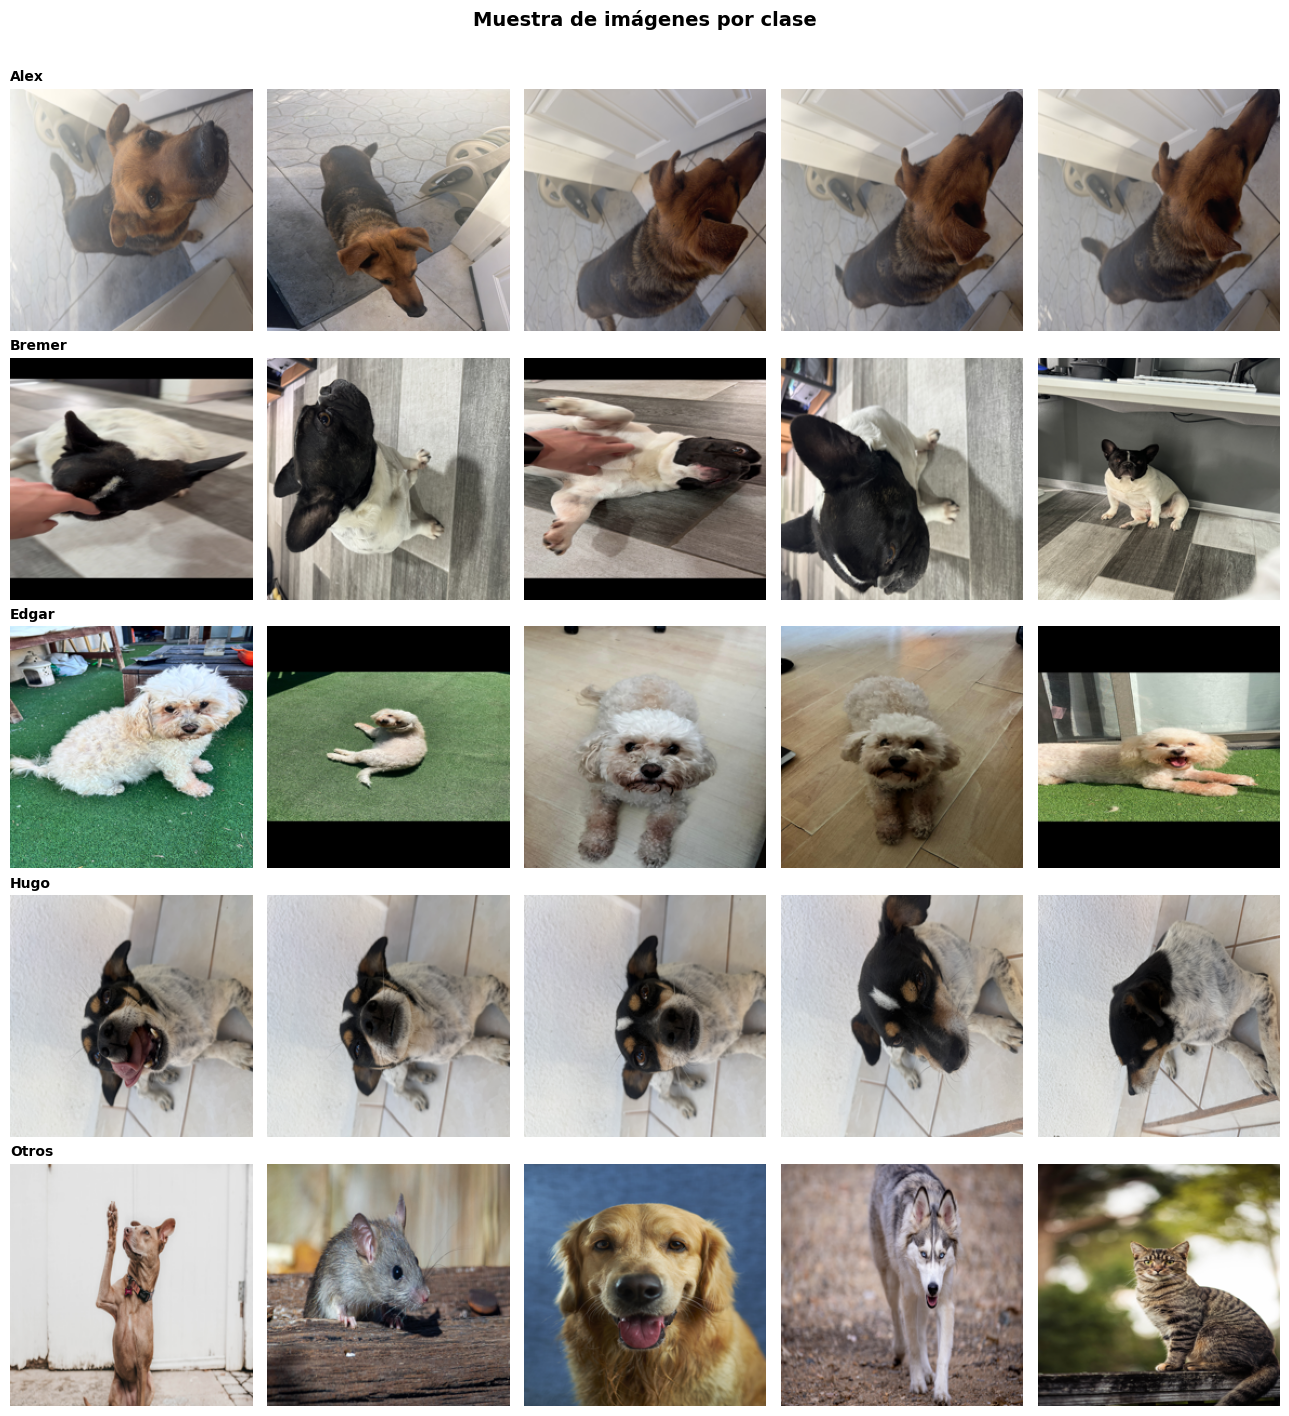

In [8]:
# Muestra de 5 imagenes por clase
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(13, 2.8 * NUM_CLASSES))
if NUM_CLASSES == 1:
    axes = [axes]

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    samples = [p for p, lbl in full_dataset.samples if lbl == cls_idx]
    chosen  = random.sample(samples, min(5, len(samples)))
    for col, img_path in enumerate(chosen):
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        axes[cls_idx][col].imshow(img)
        axes[cls_idx][col].axis('off')
        if col == 0:
            axes[cls_idx][col].set_title(cls_name, fontsize=10,
                                         fontweight='bold', loc='left')

plt.suptitle('Muestra de imágenes por clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Preprocesamiento y Particion 80/10/10

In [9]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset_full = ImageFolder(root=str(DATA_DIR), transform=train_transform)
eval_dataset_full  = ImageFolder(root=str(DATA_DIR), transform=eval_transform)

# Particion
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_dataset_full.samples):
    class_indices[label].append(idx)

train_idx, val_idx, test_idx = [], [], []
for cls, indices in class_indices.items():
    random.shuffle(indices)
    n       = len(indices)
    n_train = int(0.8 * n)
    n_val   = int(0.1 * n)
    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train + n_val])
    test_idx.extend(indices[n_train + n_val:])

train_set = Subset(train_dataset_full, train_idx)
val_set   = Subset(eval_dataset_full,  val_idx)
test_set  = Subset(eval_dataset_full,  test_idx)

print(f'Train: {len(train_set)} imágenes')
print(f'Val:   {len(val_set)} imágenes')
print(f'Test:  {len(test_set)} imágenes')

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

Train: 195 imágenes
Val:   24 imágenes
Test:  26 imágenes


## 6. Funciones de Entrenamiento y Evaluacion

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=10, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):

        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader,
                    desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct      += (outputs.argmax(dim=1) == labels).sum().item()
            total        += labels.size(0)
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        epoch_train_loss = running_loss / total
        epoch_train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs    = model(inputs)
                val_loss  += criterion(outputs, labels).item() * inputs.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total  += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc  = val_correct / val_total

        if scheduler:
            scheduler.step()

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f'Epoch {epoch+1:02d}/{num_epochs} | '
              f'Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.4f}')

    print(f'\n Mejor Val Acc: {best_val_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history


def plot_curves(history, title='Curvas de Aprendizaje'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(epochs, history['train_loss'], 'o-',  label='Train', color='steelblue')
    ax1.plot(epochs, history['val_loss'],   's--', label='Val',   color='tomato')
    ax1.set_title('Pérdida'); ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'o-',  label='Train', color='steelblue')
    ax2.plot(epochs, history['val_acc'],   's--', label='Val',   color='tomato')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def get_val_acc(history):
    return max(history['val_acc'])


def evaluate_on_test(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    print('\nReporte de Clasificación (Test Set) ')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Matriz de Confusión (Test Set)', fontsize=13, fontweight='bold')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


print('Funciones definidas')

Funciones definidas


## 7. Modelo 1: ResNet-18

### 7.1 Transfer Learning — solo se entrena la capa de salida

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


ResNet-18 TL — entrenables: 2,565 / 11,179,077 parámetros

Entrenando ResNet-18 Transfer Learning


Epoch 1/10 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | Train Loss: 1.2961  Acc: 0.5026 | Val Loss: 0.9513  Acc: 0.6250


...

Epoch 06/10 | Train Loss: 0.3826  Acc: 0.9692 | Val Loss: 0.2826  Acc: 1.0000


Epoch 07/10 | Train Loss: 0.3208  Acc: 0.9641 | Val Loss: 0.2514  Acc: 1.0000


Epoch 08/10 | Train Loss: 0.2915  Acc: 0.9744 | Val Loss: 0.2104  Acc: 1.0000


Epoch 09/10 | Train Loss: 0.2161  Acc: 0.9846 | Val Loss: 0.1866  Acc: 1.0000


Epoch 10/10 | Train Loss: 0.2235  Acc: 0.9744 | Val Loss: 0.1835  Acc: 1.0000

 Mejor Val Acc: 1.0000


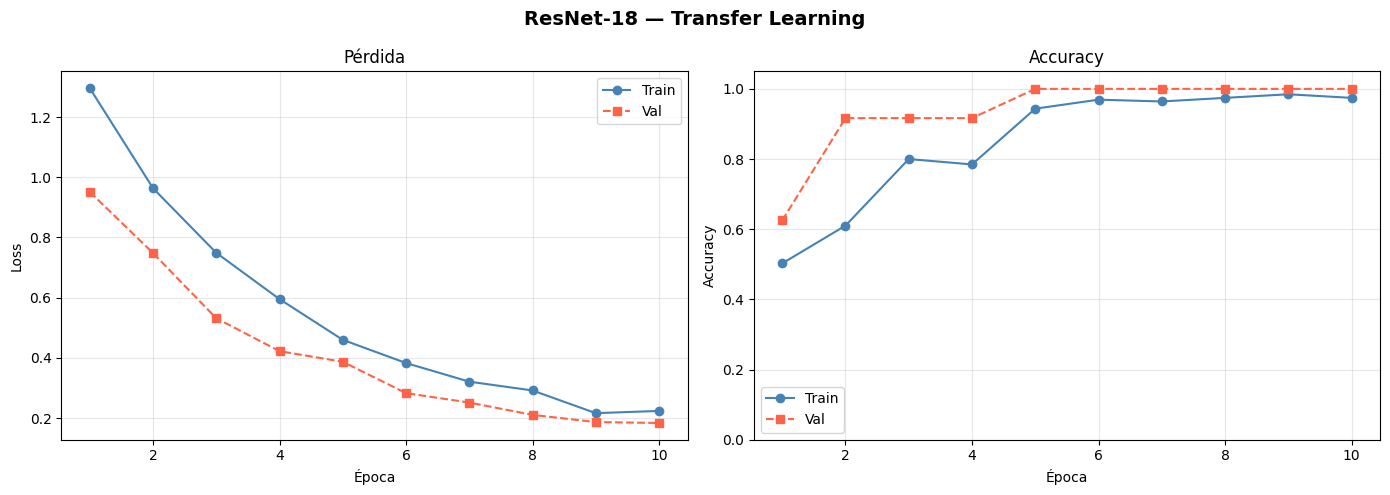

In [11]:
def build_resnet18_tl(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False       # congelar todo
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


resnet_tl = build_resnet18_tl(NUM_CLASSES)

trainable = sum(p.numel() for p in resnet_tl.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_tl.parameters())
print(f'ResNet-18 TL — entrenables: {trainable:,} / {total:,} parámetros')

criterion_r1 = nn.CrossEntropyLoss()
optimizer_r1 = optim.Adam(resnet_tl.fc.parameters(), lr=1e-3)

print('\nEntrenando ResNet-18 Transfer Learning')
resnet_tl, hist_resnet_tl = train_model(
    resnet_tl, train_loader, val_loader,
    criterion_r1, optimizer_r1, num_epochs=10
)
plot_curves(hist_resnet_tl, 'ResNet-18 — Transfer Learning')

### 7.2 Fine-Tuning — se descongela `layer4`

ResNet-18 FT — entrenables: 8,396,293 / 11,179,077 parámetros

Entrenando ResNet-18 Fine-Tuning 


Epoch 01/10 | Train Loss: 0.2752  Acc: 0.9641 | Val Loss: 0.0929  Acc: 1.0000


Epoch 02/10 | Train Loss: 0.0496  Acc: 1.0000 | Val Loss: 0.0310  Acc: 1.0000


Epoch 03/10 | Train Loss: 0.0332  Acc: 0.9897 | Val Loss: 0.0139  Acc: 1.0000


Epoch 04/10 | Train Loss: 0.0104  Acc: 1.0000 | Val Loss: 0.0097  Acc: 1.0000


...

Epoch 06/10 | Train Loss: 0.0062  Acc: 1.0000 | Val Loss: 0.0045  Acc: 1.0000


Epoch 07/10 | Train Loss: 0.0063  Acc: 1.0000 | Val Loss: 0.0054  Acc: 1.0000


Epoch 08/10 | Train Loss: 0.0068  Acc: 1.0000 | Val Loss: 0.0063  Acc: 1.0000


Epoch 09/10 | Train Loss: 0.0216  Acc: 0.9897 | Val Loss: 0.0040  Acc: 1.0000


Epoch 10/10 | Train Loss: 0.0182  Acc: 0.9949 | Val Loss: 0.0035  Acc: 1.0000

 Mejor Val Acc: 1.0000


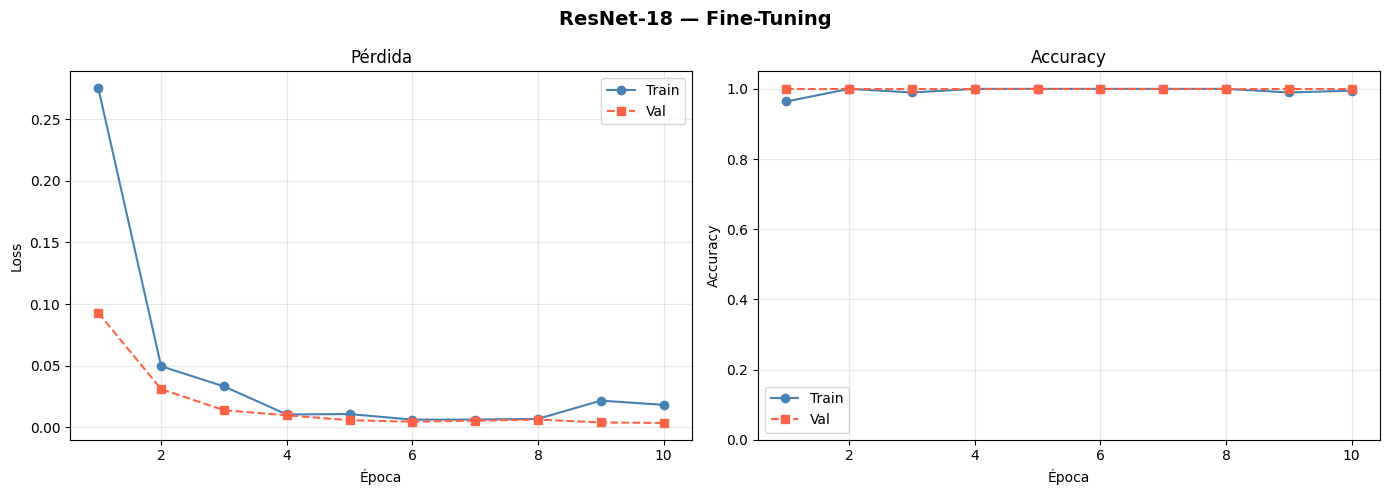

In [12]:
def build_resnet18_ft(tl_model):
    model = copy.deepcopy(tl_model)
    for param in model.layer4.parameters():   # descongelar
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    return model


resnet_ft = build_resnet18_ft(resnet_tl)

trainable = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet_ft.parameters())
print(f'ResNet-18 FT — entrenables: {trainable:,} / {total:,} parámetros')

criterion_r2 = nn.CrossEntropyLoss()
optimizer_r2 = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_ft.parameters()), lr=1e-4
)
scheduler_r2 = optim.lr_scheduler.StepLR(optimizer_r2, step_size=5, gamma=0.5)

print('\nEntrenando ResNet-18 Fine-Tuning ')
resnet_ft, hist_resnet_ft = train_model(
    resnet_ft, train_loader, val_loader,
    criterion_r2, optimizer_r2, num_epochs=10, scheduler=scheduler_r2
)
plot_curves(hist_resnet_ft, 'ResNet-18 — Fine-Tuning')

## 8. Modelo 2: MobileNetV3-Small

### 8.1 Transfer Learning

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 113MB/s]


MobileNetV3-Small TL — entrenables: 5,125 / 1,522,981 parámetros

 Entrenando MobileNetV3-Small Transfer Learning 


Epoch 01/10 | Train Loss: 1.4177  Acc: 0.4667 | Val Loss: 1.0155  Acc: 0.7917


Epoch 02/10 | Train Loss: 0.9614  Acc: 0.8974 | Val Loss: 0.6840  Acc: 0.8750


...

Epoch 06/10 | Train Loss: 0.3025  Acc: 0.9846 | Val Loss: 0.2847  Acc: 0.9167


Epoch 07/10 | Train Loss: 0.2706  Acc: 0.9795 | Val Loss: 0.2564  Acc: 0.9167


Epoch 08/10 | Train Loss: 0.2101  Acc: 0.9744 | Val Loss: 0.2377  Acc: 0.9583


Epoch 09/10 | Train Loss: 0.2000  Acc: 0.9846 | Val Loss: 0.2185  Acc: 0.9583


Epoch 10/10 | Train Loss: 0.1969  Acc: 0.9897 | Val Loss: 0.2022  Acc: 0.9583

 Mejor Val Acc: 0.9583


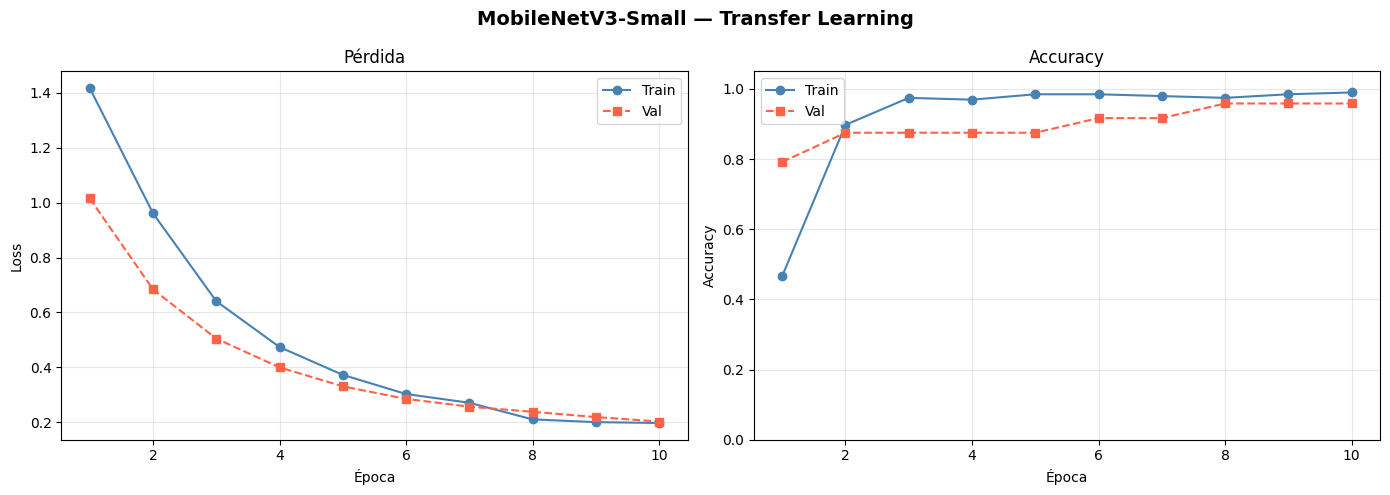

In [13]:
def build_mobilenet_tl(num_classes):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model.to(device)


mobilenet_tl = build_mobilenet_tl(NUM_CLASSES)

trainable = sum(p.numel() for p in mobilenet_tl.parameters() if p.requires_grad)
total     = sum(p.numel() for p in mobilenet_tl.parameters())
print(f'MobileNetV3-Small TL — entrenables: {trainable:,} / {total:,} parámetros')

criterion_m1 = nn.CrossEntropyLoss()
optimizer_m1 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_tl.parameters()), lr=1e-3
)

print('\n Entrenando MobileNetV3-Small Transfer Learning ')
mobilenet_tl, hist_mobilenet_tl = train_model(
    mobilenet_tl, train_loader, val_loader,
    criterion_m1, optimizer_m1, num_epochs=10
)
plot_curves(hist_mobilenet_tl, 'MobileNetV3-Small — Transfer Learning')

### 8.2 Fine-Tuning

MobileNetV3-Small FT — entrenables: 1,240,613 / 1,522,981 parámetros

Entrenando MobileNetV3-Small Fine-Tuning 


Epoch 01/10 | Train Loss: 0.2016  Acc: 0.9949 | Val Loss: 0.1852  Acc: 1.0000


Epoch 02/10 | Train Loss: 0.1479  Acc: 0.9949 | Val Loss: 0.1621  Acc: 1.0000


Epoch 03/10 | Train Loss: 0.1261  Acc: 1.0000 | Val Loss: 0.1446  Acc: 1.0000


Epoch 04/10 | Train Loss: 0.1196  Acc: 0.9897 | Val Loss: 0.1352  Acc: 1.0000


...

Epoch 06/10 | Train Loss: 0.0923  Acc: 1.0000 | Val Loss: 0.1194  Acc: 1.0000


Epoch 07/10 | Train Loss: 0.1028  Acc: 1.0000 | Val Loss: 0.1178  Acc: 1.0000


Epoch 08/10 | Train Loss: 0.0914  Acc: 1.0000 | Val Loss: 0.1159  Acc: 1.0000


Epoch 09/10 | Train Loss: 0.0947  Acc: 0.9897 | Val Loss: 0.1164  Acc: 1.0000


Epoch 10/10 | Train Loss: 0.0912  Acc: 0.9897 | Val Loss: 0.1175  Acc: 1.0000

 Mejor Val Acc: 1.0000


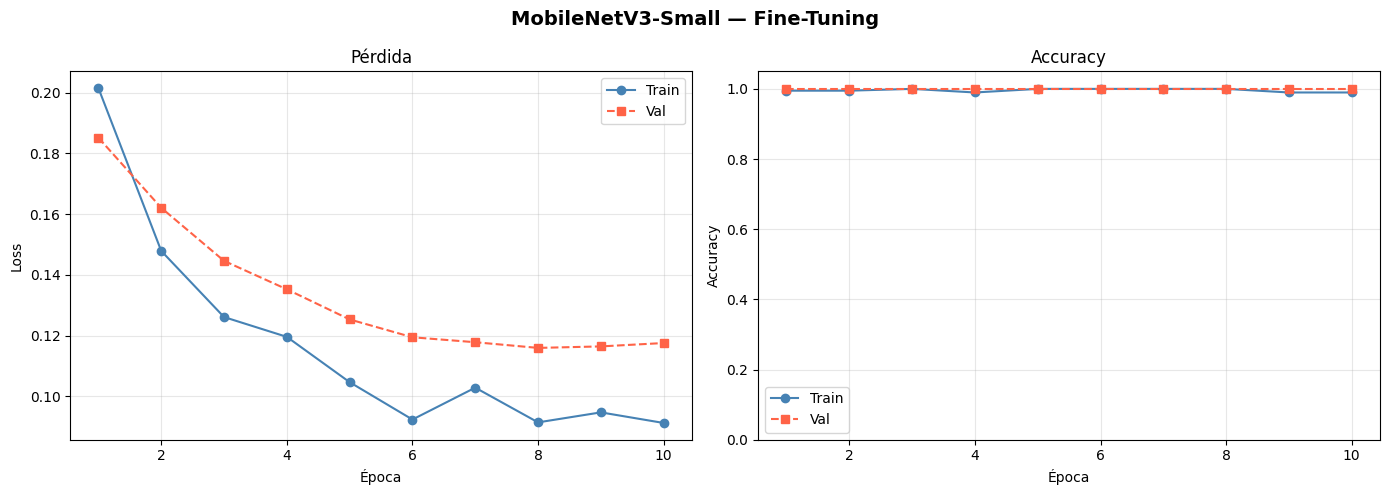

In [14]:
def build_mobilenet_ft(tl_model):
    model = copy.deepcopy(tl_model)
    for layer in list(model.features.children())[-3:]:
        for param in layer.parameters():
            param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model


mobilenet_ft = build_mobilenet_ft(mobilenet_tl)

trainable = sum(p.numel() for p in mobilenet_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in mobilenet_ft.parameters())
print(f'MobileNetV3-Small FT — entrenables: {trainable:,} / {total:,} parámetros')

criterion_m2 = nn.CrossEntropyLoss()
optimizer_m2 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_ft.parameters()), lr=5e-5
)
scheduler_m2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_m2, T_max=10)

print('\nEntrenando MobileNetV3-Small Fine-Tuning ')
mobilenet_ft, hist_mobilenet_ft = train_model(
    mobilenet_ft, train_loader, val_loader,
    criterion_m2, optimizer_m2, num_epochs=10, scheduler=scheduler_m2
)
plot_curves(hist_mobilenet_ft, 'MobileNetV3-Small — Fine-Tuning')

## 9. Comparación de Modelos

Comparación de Modelos (Val Accuracy)
Modelo                       Val Acc
ResNet-18 TL                  1.0000
ResNet-18 FT                  1.0000
MobileNetV3-Small FT          1.0000
MobileNetV3-Small TL          0.9583

Mejor modelo: ResNet-18 TL (Val Acc = 1.0000)


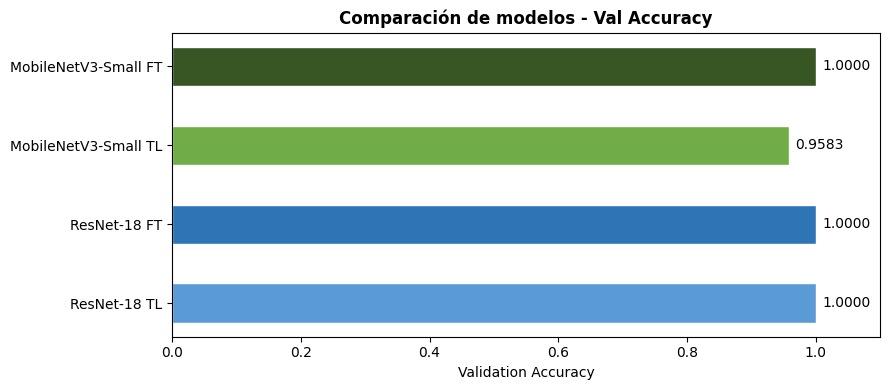

In [16]:
results = {
    'ResNet-18 TL':         (get_val_acc(hist_resnet_tl),    resnet_tl),
    'ResNet-18 FT':         (get_val_acc(hist_resnet_ft),    resnet_ft),
    'MobileNetV3-Small TL': (get_val_acc(hist_mobilenet_tl), mobilenet_tl),
    'MobileNetV3-Small FT': (get_val_acc(hist_mobilenet_ft), mobilenet_ft),
}

print('Comparación de Modelos (Val Accuracy)')
print(f'{"Modelo":<25} {"Val Acc":>10}')
for name, (acc, _) in sorted(results.items(), key=lambda x: -x[1][0]):
    print(f'{name:<25} {acc:>10.4f}')

best_name, (best_acc, best_model) = max(results.items(), key=lambda x: x[1][0])
print(f'\nMejor modelo: {best_name} (Val Acc = {best_acc:.4f})')

# Gráfica comparativa
names  = list(results.keys())
accs   = [v[0] for v in results.values()]
colors = ['#5B9BD5', '#2E75B6', '#70AD47', '#375623']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, accs, color=colors, edgecolor='white', height=0.5)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Validation Accuracy')
ax.set_title('Comparación de modelos - Val Accuracy', fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 10. evaluacion minal del mejor modelo en test Set

Evaluando "ResNet-18 TL" en el Test Set


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Reporte de Clasificación (Test Set) 
              precision    recall  f1-score   support

        Alex       1.00      1.00      1.00         4
      Bremer       0.80      1.00      0.89         4
       Edgar       1.00      1.00      1.00         3
        Hugo       1.00      1.00      1.00         3
       Otros       1.00      0.92      0.96        12

    accuracy                           0.96        26
   macro avg       0.96      0.98      0.97        26
weighted avg       0.97      0.96      0.96        26



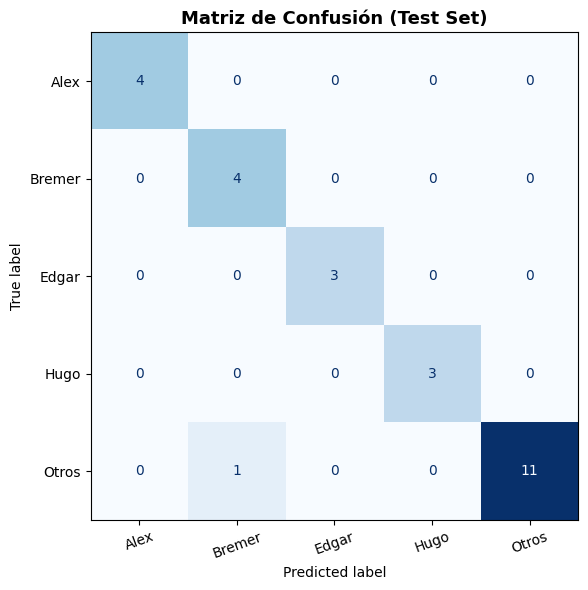

In [18]:
print(f'Evaluando "{best_name}" en el Test Set')
evaluate_on_test(best_model, test_loader, CLASS_NAMES)

## 12. Reflexión Personal

Responde estas preguntas con tus propias palabras.

---

### ¿Cuál fue el mejor modelo y por qué crees que superó a los demás?

El mejor modelo fue ResNet-18 con Transfer Learning, ya que obtuvo una accuracy de validación de 1.0000 pero es importante mencionar que MobileNetV3-Small con Transfer Learning también logró 1.0000 aun asi ResNet-18 TL fue tomado como el mejor modelo por la forma en que se hizo la comparación en el código.

Creo que los modelos con Transfer Learning superaron a los de Fine-Tuning porque nuestro dataset es relativamente pequeno en este tipo de casos las caracteristicas aprendidas previamente en ImageNet ya son suficientemente buenas para distinguir patrones importantes, y entrenar solo la ultima capa permite adaptarlas sin modificar demasiado la red por otro lado  al descongelar capas en Fine-Tuning el modelo puede ajustarse demasiado al conjunto de entrenamiento y no necesariamente mejorar en validacion

---

### Compara Transfer Learning vs. Fine-Tuning: ventajas y desventajas de cada enfoque

**Transfer Learning:**



1.   Ventajas: requiere menos tiempo de entrenamiento usa menos recursos computacionales es mas estable en datasets pequenos y reduce el riesgo de sobreajuste
2.   Desventajas: puede quedarse limitado si el nuevo problema es muy diferente al dataset original con el que fue preentrenado por que solo se adapta la ultima capa





**Fine-Tuning:**


1.   Ventajas: permite adaptar mejor el modelo al problema en especifico por que se reajustan capas internas y se puede obtener mejor desempeno cuando se cuenta con mas datos.
2.   Desventajas: requiere mas tiempo mas capacidad de computo y tiene mayor riesgo de sobreajuste especialmente cuando el dataset es pequeno como ocurrio en esta actividad.



---

### ¿Qué observaste en las curvas de aprendizaje? ¿Hubo overfitting?

En las curvas de aprendizaje observamos que los modelos con Transfer Learning tuvieron un comportamiento mas equilibrado tanto la perdida de entrenamiento como la de validacion fueron bajando con el paso de las epocas, y la accuracy en validacion se mantuvo alta eso dice que el modelo aprendio bien sin presentar senales graves de sobreajuste.

Por otro lado en los modelos con Fine-Tuning vimos que la accuracy de entrenamiento llego muy rápido a valores cercanos o iguales a 1 mientras que la accuracy de validacion se quedo en 0.9524 eso dice un leve overfitting por  que el modelo se ajusto demasiado al conjunto de entrenamiento pero no logro mejorar su capacidad de generalizacion en validacion.

---

### ¿Qué tan difícil fue construir el dataset entre los 4? ¿Qué mejorarían?

Construir el dataset fue probablemente la parte en la que mas batallamos no solo se trato de reunir imagenes sino que tambien tomo tiempo organizarnos como equipo. Hubo algunos malentendidos y como cada integrante tenia horarios diferentes se complico tener nuestras imagenes completas antes tambien fue necesario revisar la calidad de las imagenes y convertir formatos cuando hizo falta.

Para completar las imagenes que nos faltaban decidimos apoyarnos con un dataset de Kaggle especificamente el de Pets Dataset eso nos facilito bastante el trabajo y nos permitio avanzar más rapido en el conjunto de datos.

Algo que mejoraríamos seria aumentar la cantidad de imagenes propias por  que eso haria el trabajo más solido y por ultimo seria util capturar imagenes en condiciones mas variadas por ejemplo con diferentes fondos angulos e iluminaciones para que el modelo pueda generalizar mejor y no dependa tanto de caracteristicas muy especificas de las fotos.

---

### Conclusiones generales

**Edgar**: En esta actividad comprobé que los modelos preentrenados son una herramienta muy poderosa para problemas de clasificación de imagenes sobre todo cuando no se cuenta con un dataset muy grande los resultados mostraron que Transfer Learning fue suficiente para lograr el mejor desempeno mientras que Fine-Tuning no aporto una mejora adicional en este caso

**Alex**: Este proyecto fue una experiencia muy buena que me permitió aplicar conceptos de transfer learning en un contexto cercano y fácil de entender. Utilizar modelos preentrenados para identificar a nuestras mascotas me demostró el poder que tienen estas herramientas para resolver problemas reales sin necesidad de entrenar una red neuronal desde cero. Esta actividad me ayudó a cómo adaptar modelos existentes a nuevos dominios, la importancia de la calidad y organización de los datos.

**Hugo**:  Esta actividad me dejó pensando en varias cosas por ejemplo cuando tu dataset es chico, meter mas parametros al entrenamiento no siempre ayuda y pues con Fine-Tuning esperaba mejores resultados por el hecho de que se ajusta mas el modelo, pero resulto que Transfer Learning fue suficiente e incluso más estable. Creo que el aprendizaje principal fue entender que más flexible no significa más preciso (Creo que si se entiende jajajaj), y pues en general me gustó el hecho de poder meter a nuestras mascotas en trabajos ya que de alguna forma tener a alguien que quieres como un perro hace que recuerdes mas los conceptos y bases o eso creo yo. Construir el dataset y codear entre los cuatro también fue más caótico de lo que pensaba, no en el mal sentido, sino que te das cuenta de que coordinar equipos usando colab no es tan comodo que digamos por diferentes problemas que pasan.

**Bremer**: Me gusto la actividad, transfer learning es algo que no habia visto antes y ver como es el reusar un podelo preentrenado para una aplicacion mas especifica me parecio interesante, tambien me gusto que pudimos usar un dataset diferente ( nuestras mascotas )